In [1]:
# Created a conda environment 
# conda install -c conda-forge swig box2d-py
# Python version 3.10.18

In [2]:
#! pip install "gymnasium[toy-text]
#! pip install pygame
#! pip install seaborn
#! pip install matplotlib
#! pip install numpy
#! pip install scipy
#! pip install torch
#! pip install joblib

In [3]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import random
import torch
from itertools import product
import pandas as pd
from multiprocessing import Pool,  cpu_count
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ProcessPoolExecutor
from scipy.special import softmax


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [5]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
torch.cuda.is_available()

True

In [7]:
env = gym.make("Blackjack-v1", sab=True)
env.reset(seed=SEED)
env.action_space.seed(SEED)

42

A basic strategy will be used as a benchmark to test the RL algorithms performances.

In [8]:
class BasicStrategyAgent:
    def select_action(self, obs):
        player_sum, dealer_card, usable_ace = obs

        # Always stick if 20 or 21
        if player_sum >= 20:
            return 0  # Stick
        # Stick on 17+ if no usable ace
        if player_sum >= 17 and not usable_ace:
            return 0
        # Stick on 18+ with usable ace
        if usable_ace and player_sum >= 18:
            return 0
        # Otherwise, hit
        return 1  # Hit

    def evaluate_agent(self, env, max_steps, n_eval_episodes, seed=None):
        rewards = []
        for ep in range(n_eval_episodes):
            obs, _ = env.reset(seed=seed + ep if seed is not None else None)
            total_reward = 0

            for _ in range(max_steps):
                action = self.select_action(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                if terminated or truncated:
                    break

            rewards.append(total_reward)

        mean = np.mean(rewards)
        std = np.std(rewards)
        return mean, std, rewards

In [9]:
max_steps = 100
n_eval_episodes = 1000000
seed = 42

rule_agent = BasicStrategyAgent()
mean, std, _ = rule_agent.evaluate_agent(env, max_steps, n_eval_episodes, seed)
print(f"Rule-Based Agent: Mean_reward={mean:.2f} +/- {std:.2f}")

Rule-Based Agent: Mean_reward=-0.07 +/- 0.95


In [10]:
def epsilon_greedy(action_values, nA, epsilon):
    if random.random() < epsilon:
        return random.randint(0, nA - 1)
    return np.argmax(action_values)

In [11]:
def double_q_learning(env, num_episodes=1000000, alpha=0.1, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.99):
    QA = defaultdict(lambda: np.zeros(env.action_space.n))
    QB = defaultdict(lambda: np.zeros(env.action_space.n))
    reward_log_double = []
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            Q_temp = QA[state] if random.random() < 0.5 else QB[state]
            action = epsilon_greedy(Q_temp, env.action_space.n, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            reward = np.clip(reward, -1, 1)
            done = terminated or truncated
            episode_reward += reward

            if random.random() < 0.5:
                best_next = np.argmax(QA[next_state])
                target = reward + gamma * QB[next_state][best_next]
                QA[state][action] += alpha * (target - QA[state][action])
            else:
                best_next = np.argmax(QB[next_state])
                if terminated or truncated:
                    target = reward
                else:
                    target = reward + gamma * QA[next_state][best_next]
                QB[state][action] += alpha * (target - QB[state][action])

            state = next_state

        epsilon = max(min_epsilon, epsilon * decay)
        reward_log_double.append(episode_reward)

     # Merge QA and QB for final policy
    Q_final = defaultdict(lambda: np.zeros(env.action_space.n))
    for state in set(QA.keys()).union(QB.keys()):
        Q_final[state] = (QA[state] + QB[state]) / 2.0
    return Q_final, reward_log_double

In [12]:
def expected_sarsa(env, num_episodes=1000000, alpha=0.1, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.99):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    reward_log_sarsa = []
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            action_values = Q[state]
            action = epsilon_greedy(action_values, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            reward = np.clip(reward, -1, 1)
            done = terminated or truncated
            episode_reward += reward

            policy_probs = np.ones(env.action_space.n) * (epsilon / env.action_space.n)
            best_action = np.argmax(Q[next_state])
            policy_probs[best_action] += 1.0 - epsilon
            expected_q = np.dot(Q[next_state], policy_probs)

            Q[state][action] += alpha * (reward + gamma * expected_q - Q[state][action])
            state = next_state

        epsilon = max(min_epsilon, epsilon * decay)
        reward_log_sarsa.append(episode_reward)
    return Q, reward_log_sarsa

In [13]:
# Grid search over hyperparameters
hyper_grid = list(product([0.01, 0.05, 0.1], [0.99, 0.999, 0.9999, 0.99995], [0.01, 0.05, 0.1]))
best_sarsa, best_double = None, None
best_sarsa_score, best_double_score = -float("inf"), -float("inf")
best_sarsa_params, best_double_params = None, None

In [14]:
def evaluate_params(alpha, decay, min_epsilon):
    Qs, rewards_sarsa = expected_sarsa(env, alpha=alpha, decay=decay, min_epsilon=min_epsilon)
    Qd, rewards_double = double_q_learning(env, alpha=alpha, decay=decay, min_epsilon=min_epsilon)

    avg_reward_sarsa = np.mean(rewards_sarsa[-10000:])
    avg_reward_double = np.mean(rewards_double[-10000:])

    return (avg_reward_sarsa, avg_reward_double, Qs, Qd, (alpha, decay, min_epsilon))

In [15]:
# Run in parallel
results = Parallel(n_jobs=-1)(delayed(evaluate_params)(a, d, e) for a, d, e in hyper_grid)

In [16]:
for avg_sarsa, avg_double, Qs, Qd, params in results:
        if avg_sarsa > best_sarsa_score:
            best_sarsa_score = avg_sarsa
            best_sarsa = Qs
            best_sarsa_params = params

        if avg_double > best_double_score:
            best_double_score = avg_double
            best_double = Qd
            best_double_params = params

In [17]:
policy_sarsa = {s: np.argmax(a) for s, a in best_sarsa.items()}
policy_double = {s: np.argmax(a) for s, a in best_double.items()}

In [18]:
print("Best SARSA α, decay, min epsilon:", best_sarsa_params, "Score:", best_sarsa_score)
print("Best Double Q-Learning α, decay, min epsilon:", best_double_params, "Score:", best_double_score)

Best SARSA α, decay, min epsilon: (0.05, 0.9999, 0.01) Score: -0.0946
Best Double Q-Learning α, decay, min epsilon: (0.01, 0.999, 0.05) Score: -0.0734


In [32]:
# Train agents
Q_sarsa, reward_log_sarsa = expected_sarsa(env, num_episodes=1000000, alpha=0.05, gamma=1.0, epsilon=1.0, min_epsilon=0.01, decay=0.9999)
Q_double, reward_log_double = double_q_learning(env, num_episodes=1000000, alpha=0.01, gamma=1.0, epsilon=1.0, min_epsilon=0.05, decay=0.999)

In [33]:
def plot_policy(policy, usable_ace=True, title="Learned Policy"):
    data = np.full((10, 10), '', dtype=object)
    for (player, dealer, ace), action in policy.items():
        if ace == usable_ace and 12 <= player <= 21 and 1 <= dealer <= 10:
            label = 'Hit' if action == 1 else 'Stick'
            data[21 - player, dealer - 1] = label  # flip the vertical index

    heatmap_vals = np.zeros((10, 10))
    for i in range(10):
        for j in range(10):
            heatmap_vals[i, j] = 1 if data[i, j] == 'Hit' else 0

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_vals, annot=data, fmt="", cbar=False, cmap="coolwarm")
    plt.xticks(np.arange(10) + 0.5, np.arange(1, 11))
    plt.yticks(np.arange(10) + 0.5, list(reversed(np.arange(12, 22))))
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.title(f"{title} (Usable Ace = {usable_ace})")
    plt.savefig("{title}.png")
    plt.show()


In [34]:
def plot_action_probabilities(Q, usable_ace=True, title=""):
    player_range = list(range(12, 22))
    dealer_range = range(1, 11)
    hit_probs = np.empty((len(player_range), len(dealer_range)))

    for i, player in enumerate(player_range):
        for j, dealer in enumerate(dealer_range):
            state = (player, dealer, usable_ace)
            q_vals = Q.get(state, np.zeros(2))
            exp_q = np.exp(q_vals - np.max(q_vals))  # stability trick
            probs = exp_q / np.sum(exp_q)
            hit_probs[i, j] = probs[1]  # assuming action 1 = Hit

    # Flip Y-axis so 21 is on top
    hit_probs = np.flipud(hit_probs)

    plt.figure(figsize=(10, 6))
    sns.heatmap(hit_probs, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1,
                xticklabels=dealer_range, yticklabels=player_range[::-1], cbar_kws={"label": "P(Hit)"})
    plt.title(title)
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.tight_layout()
    plt.show()


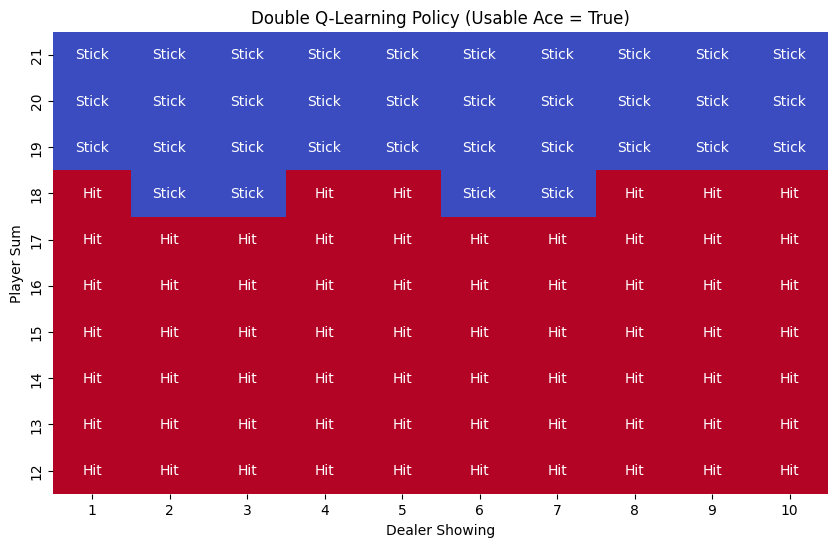

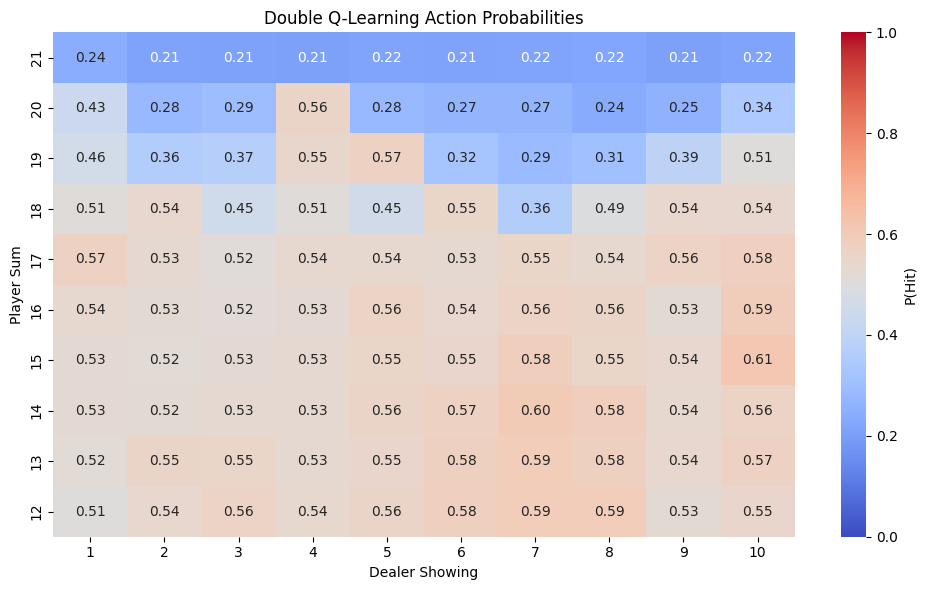

In [35]:
plot_policy(policy_double, usable_ace=True, title="Double Q-Learning Policy")
plot_action_probabilities(Q_double, usable_ace=True, title="Double Q-Learning Action Probabilities")

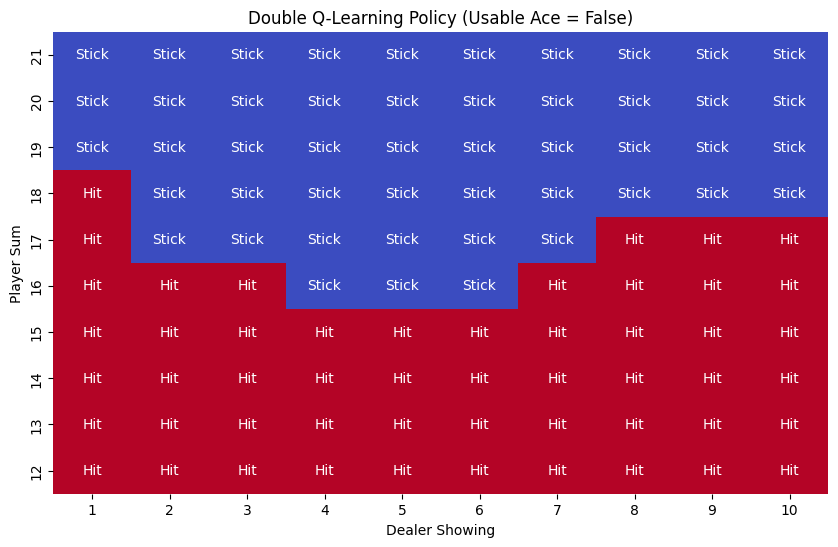

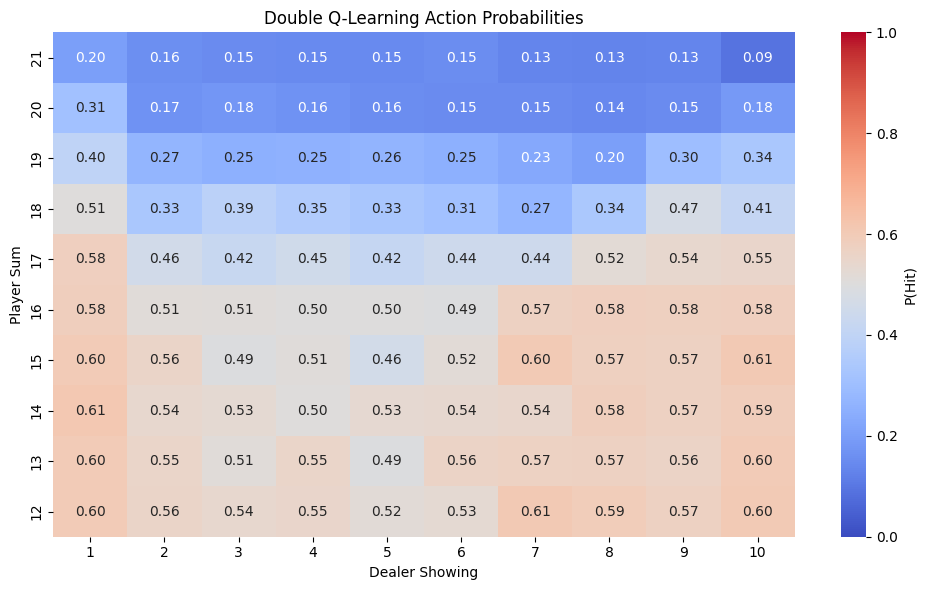

In [36]:
plot_policy(policy_double, usable_ace=False, title="Double Q-Learning Policy")
plot_action_probabilities(Q_double, usable_ace=False, title="Double Q-Learning Action Probabilities")

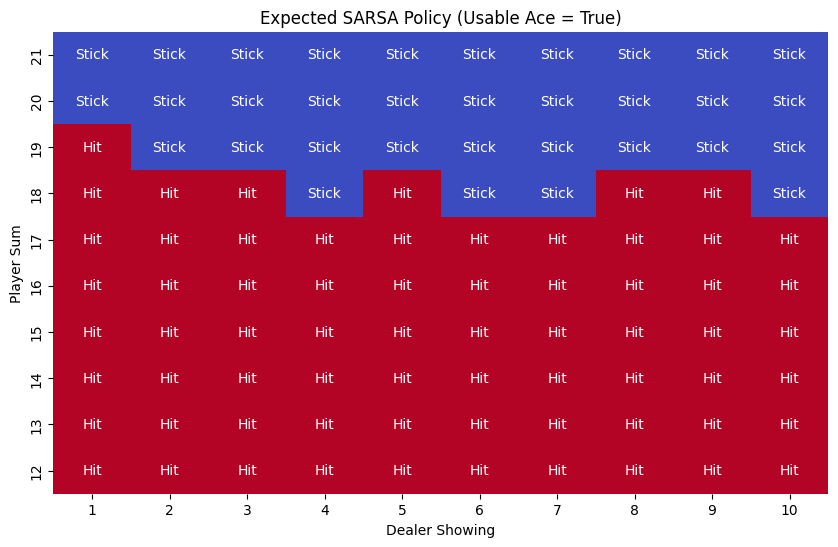

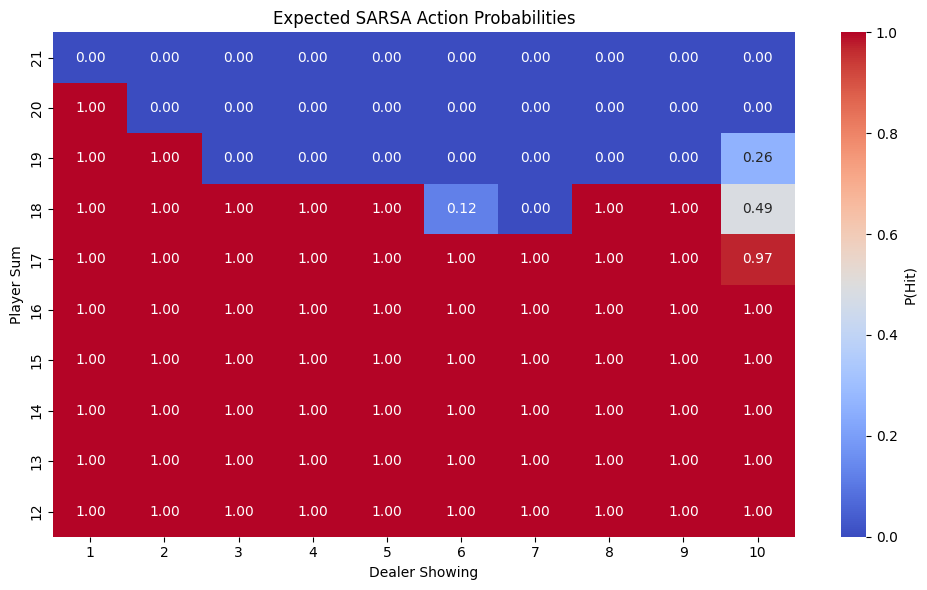

In [37]:
plot_policy(policy_sarsa, usable_ace=True, title="Expected SARSA Policy")
plot_action_probabilities(Q_sarsa, usable_ace=True, title="Expected SARSA Action Probabilities")

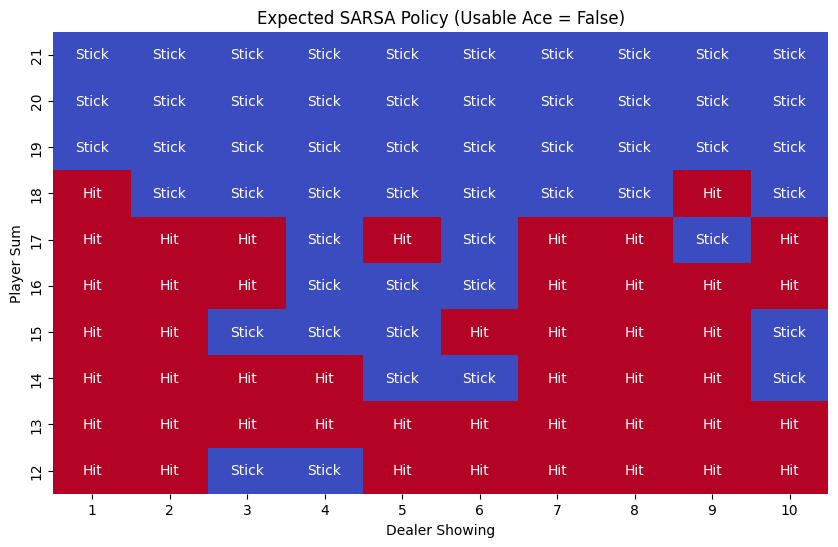

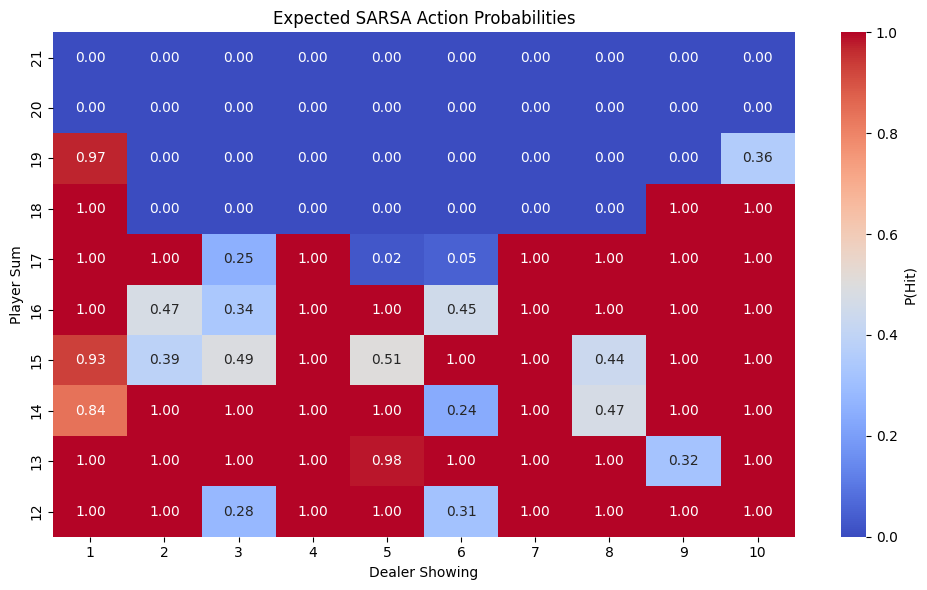

In [38]:
# Plot action probabilities
plot_policy(policy_sarsa, usable_ace=False, title="Expected SARSA Policy")
plot_action_probabilities(Q_sarsa, usable_ace=False, title="Expected SARSA Action Probabilities")

In [39]:
def evaluate_policy(policy, num_episodes=100000):
    results = {"win": 0, "lose": 0, "draw": 0}
    rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = policy.get(state, 0)  # default to stick
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)
        if reward > 0:
            results["win"] += 1
        elif reward < 0:
            results["lose"] += 1
        else:
            results["draw"] += 1

    total = sum(results.values())
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    ci95 = norm.interval(0.95, loc=mean_reward, scale=std_reward / np.sqrt(num_episodes))

    print("Evaluation Results ({} episodes):".format(num_episodes))
    for k, v in results.items():
        print(f"{k.capitalize()}: {v} ({100 * v / total:.2f}%)")
    print(f"Mean Reward: {mean_reward:.4f}, 95% CI: ({ci95[0]:.4f}, {ci95[1]:.4f})")

In [40]:
evaluate_policy(policy_double)

Evaluation Results (100000 episodes):
Win: 41309 (41.31%)
Lose: 49329 (49.33%)
Draw: 9362 (9.36%)
Mean Reward: -0.0802, 95% CI: (-0.0861, -0.0743)


In [41]:
evaluate_policy(policy_sarsa)

Evaluation Results (100000 episodes):
Win: 40969 (40.97%)
Lose: 51300 (51.30%)
Draw: 7731 (7.73%)
Mean Reward: -0.1033, 95% CI: (-0.1092, -0.0974)


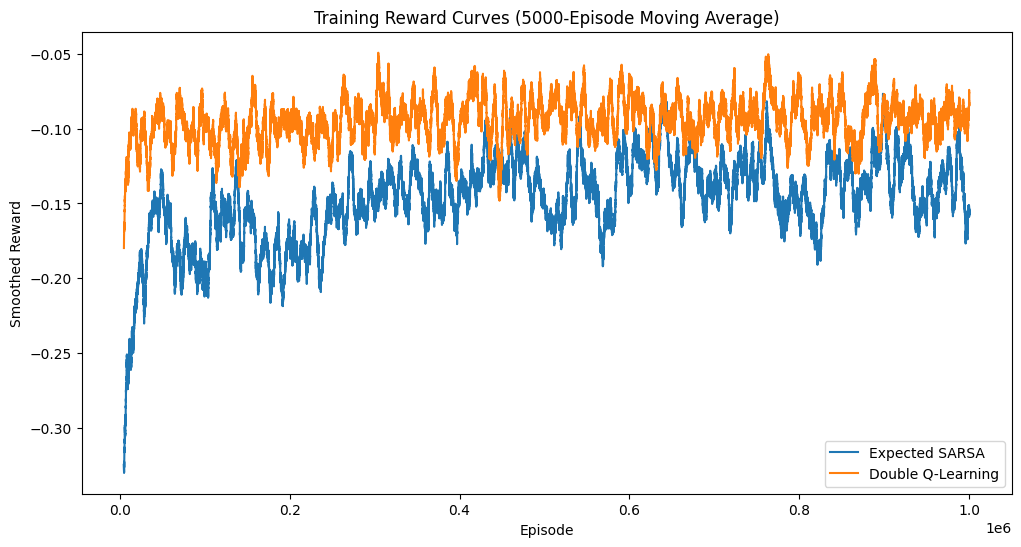

In [42]:
# Plot training reward curves
window = 5000

double_smoothed = pd.Series(reward_log_double).rolling(window).mean()
sarsa_smoothed = pd.Series(reward_log_sarsa).rolling(window).mean()

plt.figure(figsize=(12, 6))
plt.plot(sarsa_smoothed, label="Expected SARSA")
plt.plot(double_smoothed, label="Double Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Smoothed Reward")
plt.title("Training Reward Curves ({}-Episode Moving Average)".format(window))
plt.legend()
plt.savefig("Blackjack Reward Curves.png")
plt.show()

In [43]:
# Plot Value Function Heatmaps
def plot_value_function(Q, usable_ace=True, title="Value Function"):
    value = np.full((10, 10), np.nan)
    annotations = np.full((10, 10), '', dtype=object)
    for (player, dealer, ace), actions in Q.items():
        actions_np = actions.detach().cpu().numpy() if hasattr(actions, "detach") else np.array(actions)
        if ace == usable_ace and 12 <= player <= 21 and 1 <= dealer <= 10:
            val = np.max(actions_np)
            value[21 - player, dealer - 1] = val
            annotations[21 - player, dealer - 1] = f"{val:.2f}"

    best_state = np.unravel_index(np.nanargmax(value), value.shape)

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(value, cmap="viridis", annot=annotations, fmt="", xticklabels=np.arange(1, 11), yticklabels=np.arange(21, 11, -1))
    ax.add_patch(plt.Rectangle((best_state[1], best_state[0]), 1, 1, fill=False, edgecolor='red', lw=2))
    plt.xlabel("Dealer Showing")
    plt.ylabel("Player Sum")
    plt.title(f"{title} (Usable Ace = {usable_ace})")
    plt.savefig(f"{title}.png")
    plt.show()

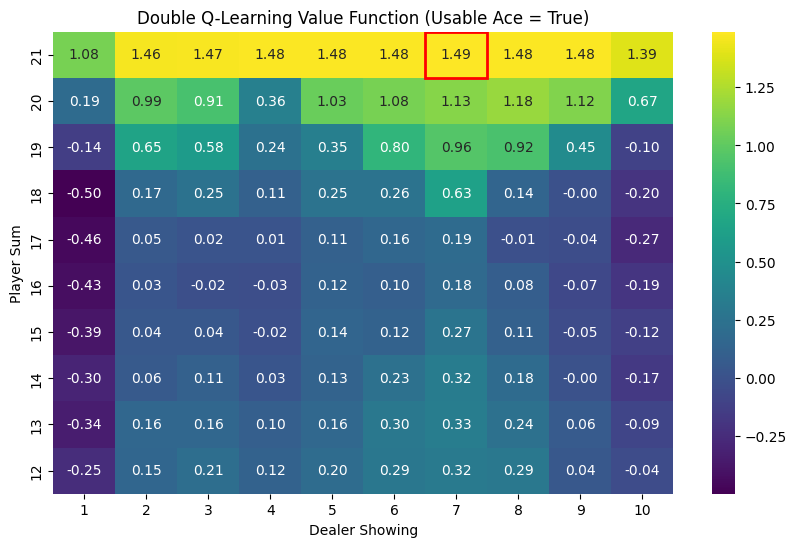

In [44]:
plot_value_function(Q_double, usable_ace=True, title="Double Q-Learning Value Function")

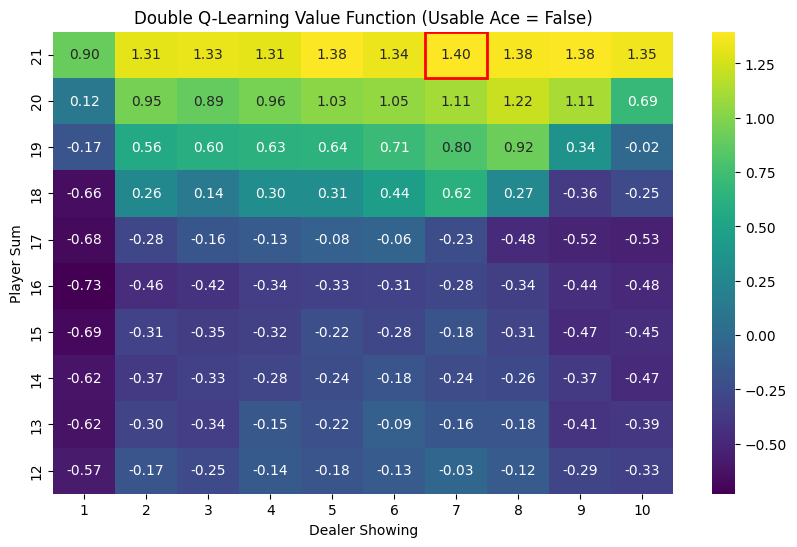

In [45]:
plot_value_function(Q_double, usable_ace=False, title="Double Q-Learning Value Function")

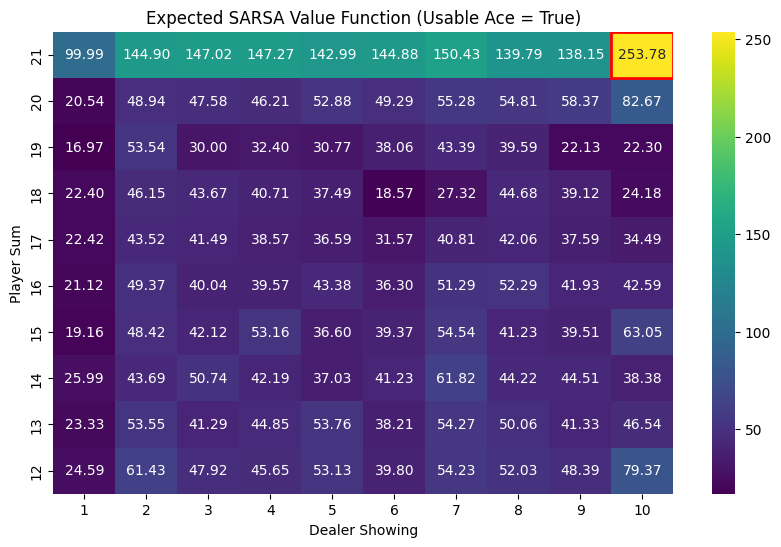

In [46]:
plot_value_function(Q_sarsa, usable_ace=True, title="Expected SARSA Value Function")

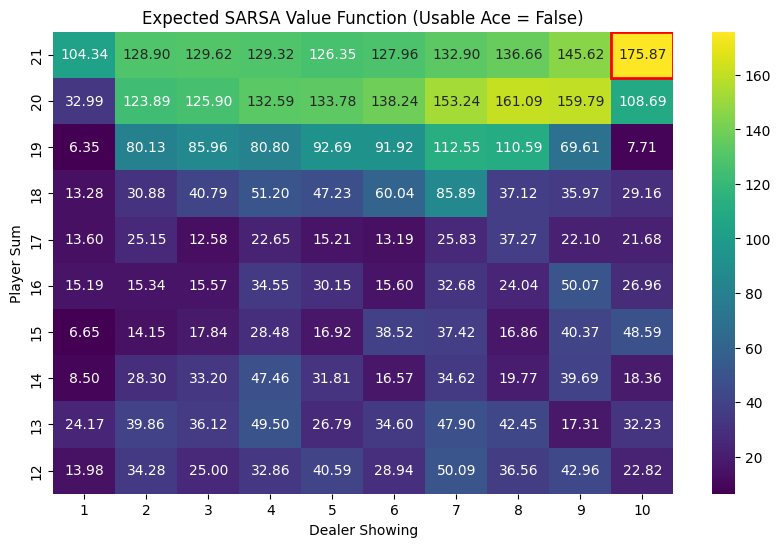

In [47]:
plot_value_function(Q_sarsa, usable_ace=False, title="Expected SARSA Value Function")

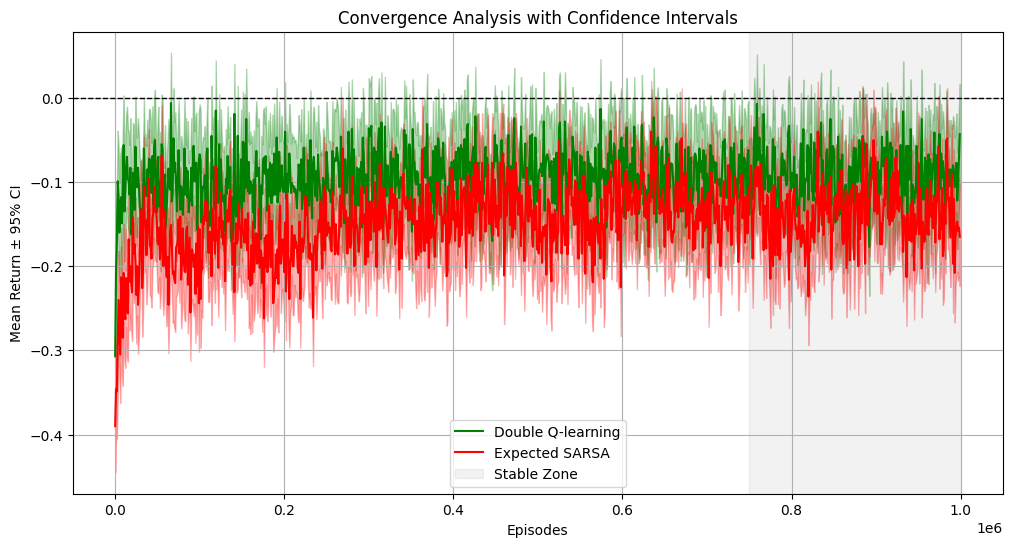

In [48]:
from scipy.stats import sem

def chunked_statistics_with_ci(rewards, chunk_size=1000):
    chunks = [rewards[i:i+chunk_size] for i in range(0, len(rewards), chunk_size)]
    means = [np.mean(chunk) for chunk in chunks]
    errors = [1.96 * sem(chunk) for chunk in chunks]  # 95% CI
    return means, errors

means_q, ci_q = chunked_statistics_with_ci(reward_log_double)
means_sarsa, ci_sarsa = chunked_statistics_with_ci(reward_log_sarsa)
episodes_q = np.arange(len(means_q)) * 1000
episodes_sarsa = np.arange(len(means_sarsa)) * 1000


plt.figure(figsize=(12, 6))
plt.plot(episodes_q, means_q, label='Double Q-learning', color='green')
plt.fill_between(episodes_q, np.array(means_q) - ci_q, np.array(means_q) + ci_q, alpha=0.3, color='green')

plt.plot(episodes_sarsa, means_sarsa, label='Expected SARSA', color='red')
plt.fill_between(episodes_sarsa, np.array(means_sarsa) - ci_sarsa, np.array(means_sarsa) + ci_sarsa, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvspan(0.75e6, 1e6, color='gray', alpha=0.1, label='Stable Zone')

plt.xlabel("Episodes")
plt.ylabel("Mean Return ± 95% CI")
plt.title("Convergence Analysis with Confidence Intervals")
plt.legend()
plt.grid(True)
plt.savefig("Convergence Analysis with Confidence Intervals.png")
plt.show()


In [49]:
def evaluate_double_q(model, env_name="Blackjack-v1", episodes=5):
    test_env = gym.make(env_name, render_mode="human")

    for ep in range(episodes):
        obs, _ = test_env.reset()
        state = obs
        total_reward = 0

        for _ in range(100):
            # Greedy action from combined Double Q-values
            Q_combined = model[state]
            action = np.argmax(Q_combined)

            obs, reward, term, trunc, _ = test_env.step(action)
            total_reward += reward
            if term or trunc:
                break
            state = model.normalize(obs)

        print(f"[Double Q] Eval Episode {ep + 1}: Total Reward = {total_reward:.1f}")

    test_env.close()

In [50]:
def get_policy_probs(Q, state, epsilon, n_actions):
    probs = np.ones(n_actions) * (epsilon / n_actions)
    best_action = np.argmax(Q[state])
    probs[best_action] += (1.0 - epsilon)
    return probs

In [51]:
def evaluate_expected_sarsa(model, env_name="Blackjack-v1", episodes=3):
    test_env = gym.make(env_name, render_mode="human")

    for ep in range(episodes):
        obs, _ = test_env.reset()#seed=seed + ep)
        state = obs
        total_reward = 0

        for _ in range(100):
            # Select action using ε-greedy or soft policy
            action_probs = get_policy_probs(model, state, epsilon=0.05, n_actions=env.action_space.n)
            action = np.random.choice(env.action_space.n, p=action_probs)

            obs, reward, term, trunc, _ = test_env.step(action)
            total_reward += reward
            if term or trunc:
                break
            state = obs

        print(f"[Expected SARSA] Eval Episode {ep + 1}: Total Reward = {total_reward:.1f}")

    test_env.close()


In [52]:
evaluate_double_q(policy_double, env_name="Blackjack-v1", episodes=5)

c:\Users\elton\anaconda3\envs\rl_env\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


[Double Q] Eval Episode 1: Total Reward = -1.0
[Double Q] Eval Episode 2: Total Reward = -1.0
[Double Q] Eval Episode 3: Total Reward = 0.0
[Double Q] Eval Episode 4: Total Reward = -1.0
[Double Q] Eval Episode 5: Total Reward = -1.0


In [53]:
evaluate_expected_sarsa(policy_sarsa, env_name="Blackjack-v1", episodes=5)

[Expected SARSA] Eval Episode 1: Total Reward = 1.0
[Expected SARSA] Eval Episode 2: Total Reward = 1.0
[Expected SARSA] Eval Episode 3: Total Reward = 1.0
[Expected SARSA] Eval Episode 4: Total Reward = -1.0
[Expected SARSA] Eval Episode 5: Total Reward = 1.0
